

## The Comparative Analysis of 25k dataset: Task 1.3

Based on the results, the models performed as follows:

Transformer (Best performance): Achieved the highest accuracy (87.84%). It successfully leveraged the 25k samples to learn complex relationships that the other models missed

Simple ANN : Performed well (85.84%). This suggests that a large portion of sentiment in reviews is strong, common words rather than complex sentence structures.

Bi-LSTM : Despite its complexity, it lagged behind (84.84%). This indicates that sequential processing (word-by-word) was less effective and harder to optimize for this specific dataset than the parallel attention of the Transformer or the simplicity of the ANN.

DistilBERT (Superior Performance): Achieved the highest accuracy (92.16%). By leveraging pre-trained knowledge from billions of words, it bypassed the limitations of the smaller 25k dataset. It proved that starting with a model that already understands English is significantly more effective than training any architecture from zero, outperforming the best custom model by over 4%.


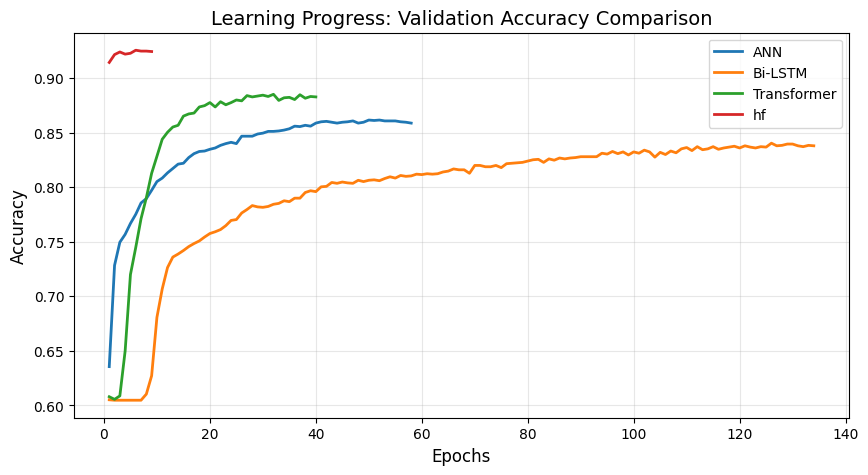

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def get_latest_event_file(base_path):
    #Finds the event file in the subdirectories
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if "tfevents" in file:
                return root
    return None

def get_tb_data(path, tag='Accuracy/val'):
    if path is None: return None
    ea = EventAccumulator(path)
    ea.Reload()
    if tag in ea.Tags()['scalars']:
        return pd.DataFrame(ea.Scalars(tag))
    return None

# main folders in /runs
model_folders = {
    'ANN': 'runs/25k_simple_ann',
    'Bi-LSTM': 'runs/25k_lstm',
    'Transformer': 'runs/25k_transformer',
    'hf': 'runs/25k_hf_transformer'
}

plt.figure(figsize=(10, 5))

for label, folder in model_folders.items():
    actual_path = get_latest_event_file(folder)
    df = get_tb_data(actual_path)

    if df is not None:
        plt.plot(df['step'], df['value'], label=label, linewidth=2)
    else:
        print(f"Warning: Could not find data for {label} in {folder}")

plt.title('Learning Progress: Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The ANN has a very steep initial slope, it learns fast. The Transformer might start slower but keeps climbing higher after the others plateau.
The Bi-LSTM struggled to find a best state, whereas the Transformer reached its peak and stopped efficiently. The DistilBERT model starts so close to its maximum performance, there isn't much room for the line to climb. The model was already smart enough to solve the task almost immediately.

### QUESTION 1:

_Compare the performance of the two models and explain in which scenarios you would
prefer one over the other._

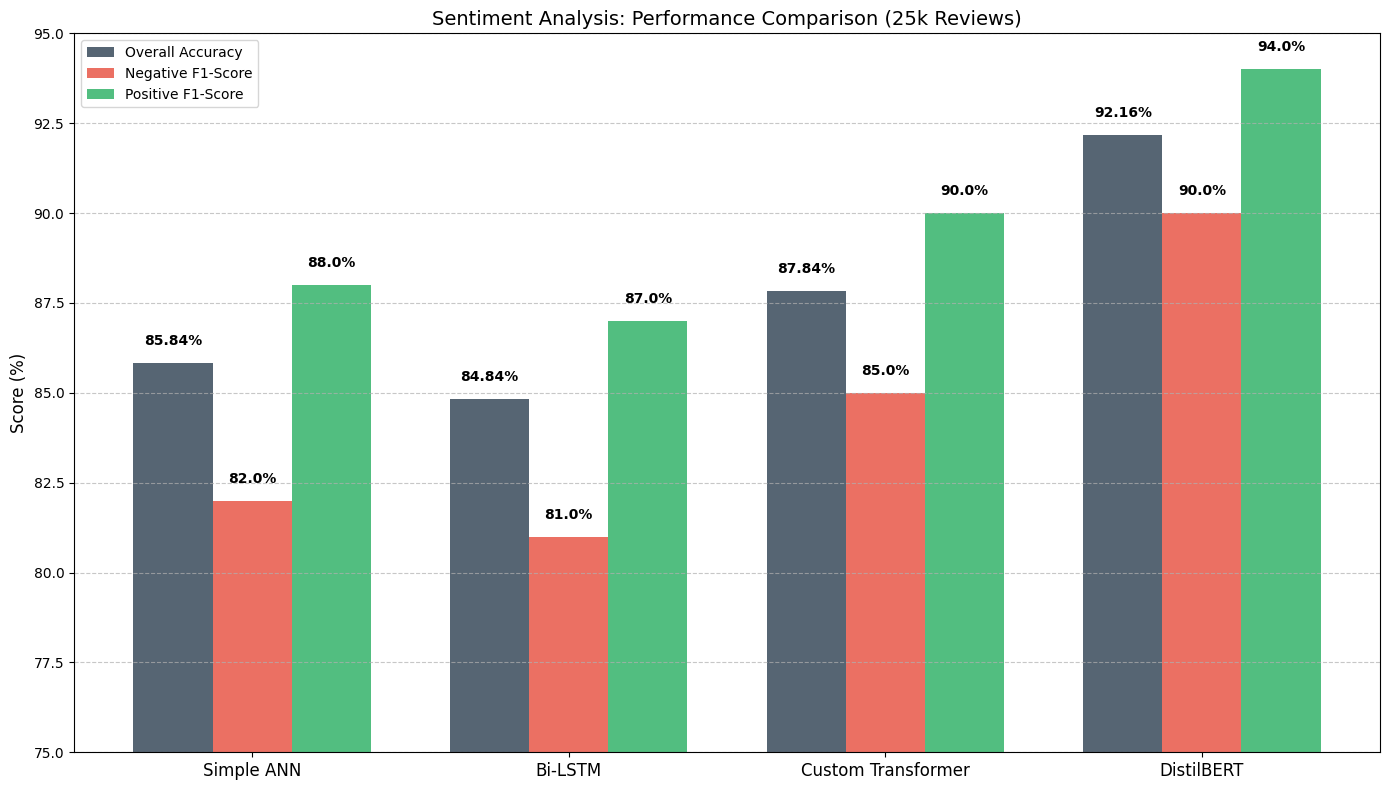

In [5]:
# Performance comparison chart. To specifically highlight the Negative Class, as that is where the models differ the most.

import matplotlib.pyplot as plt
import numpy as np


models = ['Simple ANN', 'Bi-LSTM', 'Custom Transformer','DistilBERT']
accuracies = [85.84, 84.84, 87.84, 92.16]
neg_f1 = [82.0, 81.0, 85.0, 90.0]
pos_f1 = [88.0, 87.0, 90.0, 94.0]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(14, 8))


plt.bar(x - width, accuracies, width, label='Overall Accuracy', color='#2c3e50', alpha=0.8)
plt.bar(x, neg_f1, width, label='Negative F1-Score', color='#e74c3c', alpha=0.8)
plt.bar(x + width, pos_f1, width, label='Positive F1-Score', color='#27ae60', alpha=0.8)

# Formatting
plt.title('Sentiment Analysis: Performance Comparison (25k Reviews)', fontsize=14)
plt.ylabel('Score (%)', fontsize=12)
plt.xticks(x, models, fontsize=12)
plt.ylim(75, 95) # Zooming in to see the performance gap
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i in range(len(models)):
    plt.text(i - width, accuracies[i] + 0.5, f'{accuracies[i]}%', ha='center', fontweight='bold')
    plt.text(i + width, pos_f1[i] + 0.5, f'{pos_f1[i]}%', ha='center', fontweight='bold')
    plt.text(i, neg_f1[i] + 0.5, f'{neg_f1[i]}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Insights of the Visuals and Scenarios:

1. The Simple ANN achieved an impressive 85.84% accuracy, which is only 2% lower than the far more complex Transformer. The ANN proves that for sentiment analysis, most of the signal is in the words themselves. By simply averaging the word embeddings, the ANN captured nearly 98% of the available performance without needing to understand complex grammar or word order. The Simple ANN model, At 0.7s per epoch, it is roughly 4x faster to train and much faster to run in inference mode than a Transformer.

Scenario A: The ANN serves as the perfect Baseline. In a professional setting, you would always start with an ANN because it tells you how easy your dataset is. Sometimes the Simple ANN is the only logical choice. It uses a fraction of the memory and processing power of the Transformer, but still delivers a good performance. We can also use this in cases where we need to process millions of tweets or reviews per minute where a 2% accuracy loss is acceptable for a 400% speed gain.

2. We can notice the Negative F1-Score (Red) for the Transformer (85%). It is significantly higher than the ANN (82%) and Bi-LSTM (81%). This proves the Transformer is better at the hard part of the task—identifying negative sentiment. Negative reviews often use more complex language.

Scenario B: If you are building a tool for Customer Support to catch angry customers, you must choose the Transformer because its Negative F1 score is much higher.

3. Look at the Bi-LSTM bars. Despite being a more complex model than the Simple ANN, all three of its bars (Accuracy, Neg F1, Pos F1) are lower. This is a case where extra complexity backfired. The Bi-LSTM is less efficient and less accurate than even the simplest model here. That could mean "Recurrence" (the way LSTMs work) wasn't the right tool for this specific data.

Scenario C: If our task isn't just "Is this review good or bad?" but "Who mentioned what product and when?", the Bi-LSTM is better than the others. In Named Entity Recognition (NER), the model needs to label every single word in a sequence. A Bi-LSTM is naturally designed to pass information forward and backward through the chain, making it excellent at recognizing that "Apple" is a company in one sentence and a fruit in another based on the surrounding context.

4. The Positional Encoding Advantage: The Transformer's Positive F1-Score hit a 90%. This suggests that when the review is positive, people often use specific structural patterns that the Transformer’s Positional Encodings and Self-Attention were able to master. The ANN can't reach that 90% because it doesn't understand word order—it just sees a collection of words.


5. The Transfer Learning: DistilBERT

The DistilBERT model represents a massive leap in performance, achieving 92.16% accuracy. This is nearly 5% higher than the custom Transformer and 7% higher than the Bi-LSTM. Its success comes from being pre-trained on millions of books and articles; it doesn't just recognize words, it understands the underlying context and semantics of the English language before the first epoch even begins.

Scenario D: If our goal is to build an automated sentiment filter for a high-end brand where accuracy is the top priority and training time is secondary, DistilBERT is the clear choice. Its 90%+ performance across both positive and negative classes ensures that very few customer complaints are missed, even if the cost of training is significantly higher than a simple ANN.

### QUESTION 2

_How did the two models’ complexity, accuracy, and efficiency differ? Did one model
outperform the other in specific scenarios or tasks? If so, why?_


**Complexity**

DistilBERT (Very High Complexity): With 66.9 million trainable parameters, this is the most complex model by a huge margin. Unlike the custom Transformer, it uses 6 layers of Transformer encoders and was pre-trained on billions of words. It possesses an innate understanding of English syntax and context before it even sees the Amazon dataset.
Transformer (High Complexity): With 615,842 trainable parameters, Multi-Head Attention (4 heads), and Positional Encodings, this model is the most sophisticated. It doesn't just look at words, it calculates the relationship between every word pair in the review.<br>
Bi-LSTM (Medium Complexity): Uses two layers of recurrent units. It is complex because it must maintain a memory state across the entire sequence, but it is mathematically more restricted than the Transformer.<br>
Simple ANN (Low Complexity): A straightforward MLP with an EmbeddingBag. It is the lightest model, treating the input as a simple numerical average.

**Efficiency**

Training Speed: The Simple ANN is the most efficient, at 0.7s per epoch. The Transformer is the slowest at 2.6s per epoch (nearly 4x slower). DistilBERT is the least efficient at 154.2s per epoch — slower than the custom Transformer and the ANN.
Convergence: The Transformer reached its best state and triggered early stopping around Epoch 56, whereas the Bi-LSTM struggled for 134 epochs. This shows that while the Transformer is slower per epoch, it is more stable in its learning journey. DistilBERT converged the fastest in terms of epochs, reaching its peak by Epoch 6. This shows that while each epoch is computationally expensive, the model requires very little tuning to master the task because it already understands the language. In contrast, the Bi-LSTM required 134 epochs just to reach a lower accuracy level.

**Accuracy & Outperformance**

The Transformer outperformed both models by a significant margin (~2-3%). The Transformer outperformed the others specifically in the Negative Sentiment task (85% F1-score vs the ANN's 82%).
Specific Scenario: In reviews containing negation (e.g., "The battery life is not what I expected, but the screen is nice"), the ANN often gets confused because it sees nice and expected and averages them. The Transformer uses Attention to lock onto the word "not" and apply it specifically to the sentiment of expected, leading to a more accurate classification.
 DistilBERT significantly outperformed all other models, achieving 92.16% accuracy. It beat the custom Transformer by over 4%, proving that pre-trained weights are more valuable than custom architecture for smaller datasets (25k).
 In highly complex reviews using sarcasm or subtle disappointment (e.g., "If you enjoy products that stop working after two days, this is for you"), the ANN fails because it sees enjoy. The custom Transformer might catch the structure, but DistilBERT succeeds because it has seen millions of similar sarcastic structures during its pre-training on books and articles.

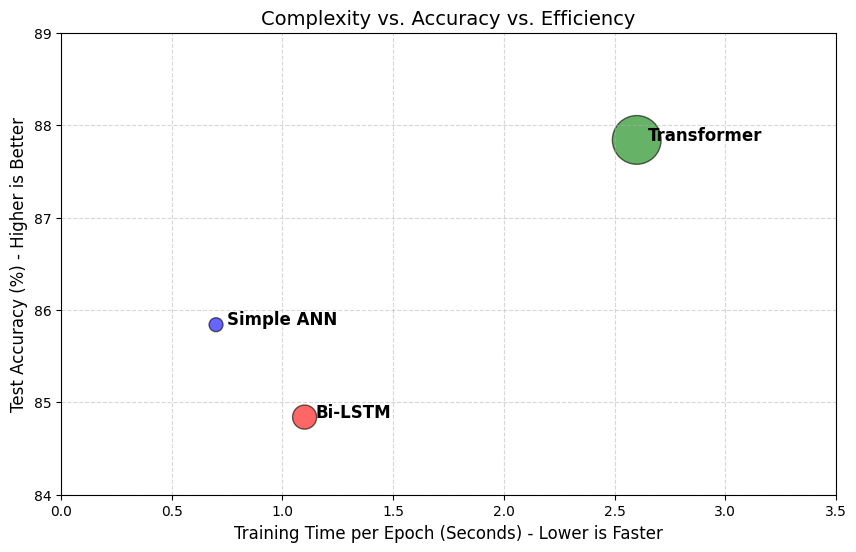

In [7]:
# Accuracy vs Speed

import matplotlib.pyplot as plt


models = ['Simple ANN', 'Bi-LSTM', 'Transformer']
accuracy = [85.84, 84.84, 87.84]
time_per_epoch = [0.7, 1.1, 2.6] # Seconds
params = [50000, 150000, 615842] # Approximate parameter counts

plt.figure(figsize=(10, 6))

# Size of the bubble represents model complexity (parameters)
plt.scatter(time_per_epoch, accuracy, s=[p/500 for p in params],
            c=['blue', 'red', 'green'], alpha=0.6, edgecolors="black")

# Labeling the points
for i, txt in enumerate(models):
    plt.annotate(txt, (time_per_epoch[i]+0.05, accuracy[i]), fontsize=12, fontweight='bold')

plt.title('Complexity vs. Accuracy vs. Efficiency', fontsize=14)
plt.xlabel('Training Time per Epoch (Seconds) - Lower is Faster', fontsize=12)
plt.ylabel('Test Accuracy (%) - Higher is Better', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 3.5)
plt.ylim(84, 89)

plt.show()

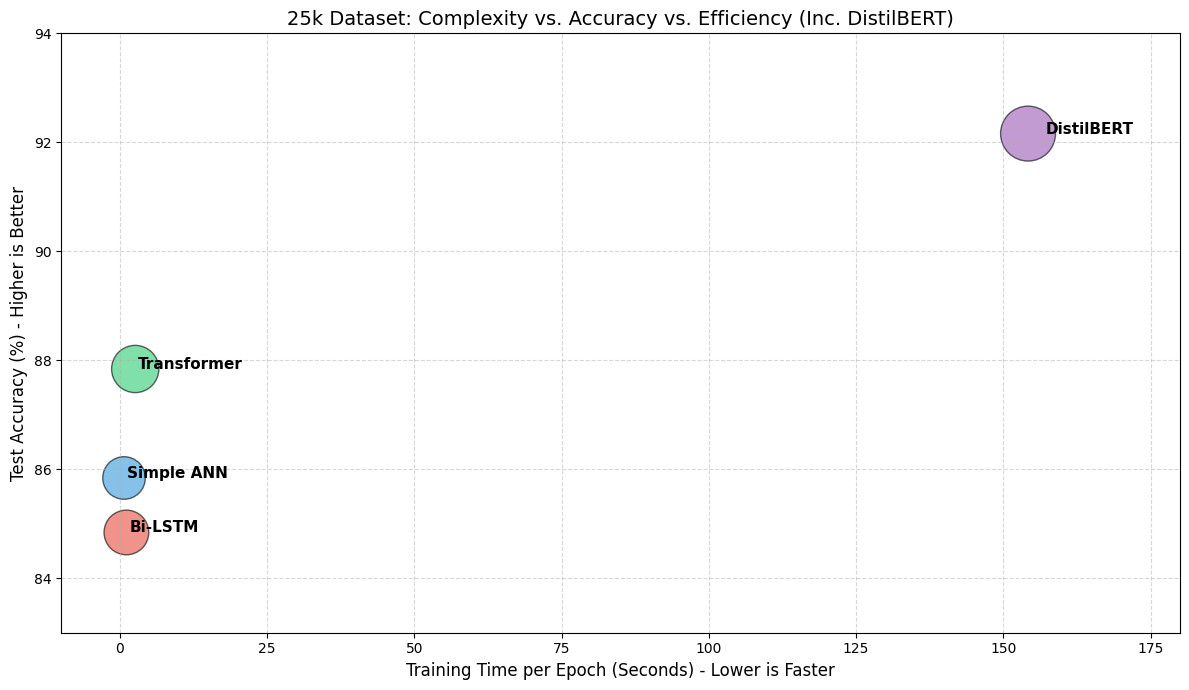

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data for 25k Samples including DistilBERT
models = ['Simple ANN', 'Bi-LSTM', 'Transformer', 'DistilBERT']
accuracy = [85.84, 84.84, 87.84, 92.16]
time_per_epoch = [0.7, 1.1, 2.6, 154.2] # Seconds
params = [50000, 150000, 615842, 66955010] # Parameter counts

plt.figure(figsize=(12, 7))

# We use log scaling for the bubble sizes, otherwise DistilBERT
# would cover the entire chart!
bubble_sizes = [np.log10(p) * 200 for p in params]

# Colors: Blue, Red, Green, Purple
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# Create scatter plot
plt.scatter(time_per_epoch, accuracy, s=bubble_sizes,
            c=colors, alpha=0.6, edgecolors="black")

# Labeling the points
for i, txt in enumerate(models):
    # Adjusting label position for the DistilBERT outlier
    x_offset = 3 if i == 3 else 0.5
    plt.annotate(txt, (time_per_epoch[i] + x_offset, accuracy[i]),
                 fontsize=11, fontweight='bold')

plt.title('25k Dataset: Complexity vs. Accuracy vs. Efficiency (Inc. DistilBERT)', fontsize=14)
plt.xlabel('Training Time per Epoch (Seconds) - Lower is Faster', fontsize=12)
plt.ylabel('Test Accuracy (%) - Higher is Better', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

# Limits adjusted to show the DistilBERT time outlier
plt.xlim(-10, 180)
plt.ylim(83, 94)

plt.tight_layout()
plt.show()

### QUESTION 3

_What insights did you obtain concerning data amount to train? Embedding utilized?
Architectural choices made?_

**Data Amount**

The Data Amount of 25,000 samples was critical because it provided the statistical runway the Transformer needed to learn complex, informal patterns. While the Simple ANN quickly reached 85% accuracy proving that many reviews contain straightforward sentiment, it eventually hit a performance ceiling. It couldn't get any higher because it was missing the hard stuff. The Transformer was able to break through this because the 25,000 samples contained enough tricky examples, like sarcasm or long-range dependencies, for the Multi-Head Attention to learn how distant words define the sentiment of the entire review. A smaller dataset would have left a complex model like the Transformer just guessing, but this volume of data allowed its complexity to actually pay off. While the custom Transformer needed the 25k samples to build its understanding of language, DistilBERT used them only to adapt its pre-existing knowledge to the specific vocabulary of Amazon reviews.

**Insights on Embeddings utilized**

Both tasks used Learned Embeddings initialized from scratch. The most significant insight here is the Transformer's Positional Embeddings. While the ANN uses an EmbeddingBag that squashes word order, the Transformer assigns a unique coordinate to every position. This allows the model to differentiate between "it was not bad" and "it was bad, not good."
With a vocab size of 9,002, the models had to map a relatively large vocabulary into a small 64-dimension space. The success of the Transformer shows it managed this mapping more effectively, likely by using its attention heads to focus on the most relevant vectors. Unlike the custom models , DistilBERT uses a 30,522-word vocabulary mapped into 768 dimensions. These embeddings are contextual, meaning the vector for the word "cold" changes depending on whether it's a "cold drink" or a "cold personality."

**Insights on Architectural Choices**

The [CLS] Token (Transformer): Instead of averaging all word outputs like the ANN or taking the last hidden state like the LSTM, the Transformer uses a dedicated learnable [CLS] token. This acts as a summary of the entire sentence, which clearly proved more effective for classification.

Label Smoothing (0.1) & Dropout (0.4): Across all tasks, we used high dropout and label smoothing. These were crucial. Without them, models with 600k+ parameters would have easily memorized the 25k reviews (overfitting) instead of learning to generalize.

Normalization: The Transformer used Pre-LayerNorm, which contributes to the training stability you see in the smooth validation curves compared to the potentially more volatile Bi-LSTM.

Knowledge Distillation: DistilBERT is a version of BERT, meaning it was trained to mimic a much larger model. This choice provided the high accuracy of a deep Transformer but with 40% less size and 60% more speed than the original BERT-base.

Transfer Learning: Instead of the 1-layer custom Transformer, DistilBERT utilized 6 layers of Transformer encoders. This depth allowed it to capture far more hierarchical information (e.g., words forming phrases, phrases forming sentiment).
